In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

df_skills = pd.DataFrame(data)

df_skills

,job_title_short,job_skills
0,Data Analyst,"[excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


In [3]:
df_skills.explode(['job_skills']).value_counts('job_skills')

job_skills
python     3
airflow    1
aws        1
excel      1
r          1
sql        1
Name: count, dtype: int64

In [4]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [5]:
df[['job_title_short', 'job_skills']].head()

,job_title_short,job_skills
0,Senior Data Engineer,None
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [6]:
df_exploded = df.explode('job_skills')
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()
skills_count


job_title_short    job_skills
Business Analyst   airflow        318
                   airtable        17
                   alteryx       1078
                   angular         87
                   ansible        120
                                 ... 
Software Engineer  wrike            4
                   wsl             13
                   xamarin         35
                   yarn           145
                   zoom           229
Length: 2256, dtype: int64

In [7]:
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=True)
df_skills_count

,job_title_short,job_skills,skill_count
1157,Machine Learning Engineer,asp.net core,1
2187,Software Engineer,rubyon rails,1
1983,Senior Data Scientist,symfony,1
1289,Machine Learning Engineer,powerbi,1
776,Data Engineer,linode,1
...,...,...,...
1101,Data Scientist,sql,78982
625,Data Analyst,sql,92428
830,Data Engineer,python,108022
865,Data Engineer,sql,113130


In [8]:
job_title = 'Data Engineer'
top_skills = 10
df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].tail(top_skills)

Text(0, 0.5, 'Skills')

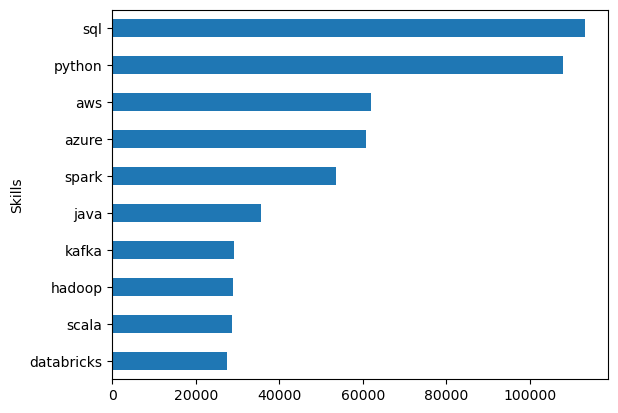

In [10]:
df_skill_final.plot(kind='barh', x= 'job_skills', y='skill_count')
plt.legend().set_visible(False)
plt.ylabel('Skills')